# Particle Number Parameter Sweep

This notebook studies how the numerical resolution of the CDM spike affects the measured SMBH hardening. The total spike mass is fixed while the number of tracer particles is varied.

The diagnostic quantity is the SMBH separation as a function of time. A lower final separation means that the CDM spike extracted more orbital energy before becoming depleted.

Scanned parameter: number of CDM tracer particles.


# Imports and Global Parameters

Define the binary, units, integration time, Schwarzschild radius, and the array of parameter values used in the sweep.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from cdm_spike_utils import (
    add_volume_uniform_spike,
    apply_publication_style,
    configure_smbh_collisions,
    create_smbh_binary,
    moving_average,
    plot_parameter_sweep,
    schwarzschild_radius_au,
    separation_history,
)

# Define the SMBH binary parameters.
M_1 = 3e9
q = 1
M_2 = q * M_1
M_total = M_1 + M_2
R_sch = schwarzschild_radius_au(M_1)
print(f"The Schwarzschild radius is {R_sch} AU")

# Simulation parameters.
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years / N_frames
M_spike_total = 0.1 * M_1
radius_spike = 400000
avg_distance_tot = []
N_particles_array = np.linspace(10, 120, 20).astype(int)


The Schwarzschild radius is 59.238711673042346 AU


# Run the Sweep

For each parameter value, a new `rebound` simulation is initialized. The CDM particles are generated with the same random seed so differences between curves mainly reflect the scanned parameter rather than a different random realization.


In [2]:
for m in trange(len(N_particles_array), desc="Processing"):
    sim, black_hole_1, black_hole_2, M_2, M_total = create_smbh_binary(M_1, q=q)

    # Keep the same spike mass used in the original sweep cell.
    M_spike_total = 0.4 * M_1
    N_particles = int(N_particles_array[m])
    m_single_dm = add_volume_uniform_spike(
        sim,
        n_particles=N_particles,
        total_spike_mass=M_spike_total,
        m_central=M_total,
        r_min=1000,
        r_max=radius_spike,
        seed=0,
    )

    configure_smbh_collisions(sim, R_sch, softening=True)
    bh_distance = separation_history(sim, black_hole_1, black_hole_2, N_frames, Delta_time)
    avg_distance_tot.append(moving_average(bh_distance, window=50))

    print(f'Simulation for N={N_particles} completed')


Processing:  10%|█         | 2/20 [00:00<00:02,  6.10it/s]

Simulation for N=10 completed
Simulation for N=15 completed


Processing:  15%|█▌        | 3/20 [00:00<00:03,  5.38it/s]

Simulation for N=21 completed


Processing:  20%|██        | 4/20 [00:00<00:04,  3.47it/s]

...

Simulation for N=108 completed


Processing:  95%|█████████▌| 19/20 [00:50<00:05,  5.56s/it]

Simulation for N=114 completed


Processing: 100%|██████████| 20/20 [00:58<00:00,  2.94s/it]

Simulation for N=120 completed


# Plot Separation Curves

The color of each curve encodes the scanned parameter. The late-time value of each curve gives the stalling distance for that run.


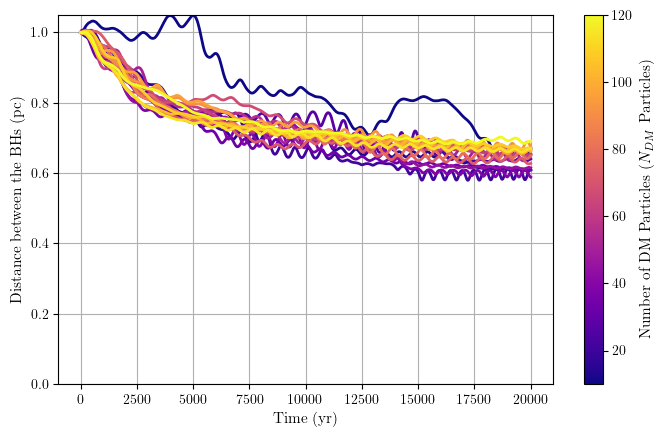

In [3]:
apply_publication_style(use_tex=True)

fig1, ax1d = plot_parameter_sweep(
    t_array=t_array,
    distance_histories=avg_distance_tot,
    parameter_values=N_particles_array,
    colorbar_label='Number of DM Particles ($N_{DM}$ Particles)',
    cmap_name='plasma',
    output_path=f'Distance_vs_time_scanning_N_M_spike={M_spike_total}_N_data=50_softened.pdf',
)

plt.show()


# Save Numerical Results

Store the separation histories in a compressed NumPy file so they can be reused for fitting or plotting without rerunning the full sweep.


In [4]:
np.savez(f'datos_Distance_vs_time_scanning_N_M_spike={M_spike_total}_softened.npz', avg_distance_tot = avg_distance_tot)
